In [19]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

from src.siac_modal import siac_cgam


In [20]:

cgam = siac_cgam(moments=4, BSorder=4)
np.allclose(cgam, cgam[::-1], atol=1e-12)

True

Integral: 0.9999999999989999
Support approx: [-1.4997  1.4997]


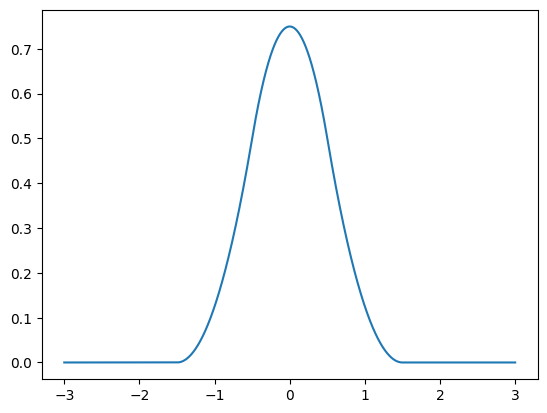

In [21]:
from src.siac_modal import centered_cardinal_bspline
p = 2
psi = centered_cardinal_bspline(p+1)

x = np.linspace(-3, 3, 20001)
vals = psi(x)

print("Integral:", np.trapezoid(vals, x))
print("Support approx:", x[vals > 1e-12][[0, -1]])
plt.plot(x, vals)

In [22]:
## 1D adaptation of nodal --> modal code 

def reference_nodes_equispaced_1d(p):
    if not isinstance(p, int):
        raise TypeError("p must be an integer.")
    if p < 0:
        raise ValueError("p must be nonnegative.")

    if p == 0:
        return np.array([0.0], dtype=float)

    return np.linspace(-1.0, 1.0, p + 1, dtype=float)


def vandermonde_1d(nodes, p, eval_basis):
    """
    Build 1D Vandermonde matrix V[i,m] = phi_m(nodes[i]).
    """
    L = eval_basis(nodes, p)   # shape (p+1, p+1), modes x nodes
    V = L.T                    # shape (nodes, modes)
    Vinv = np.linalg.inv(V)
    return V, Vinv


def nodal_to_modal_1d_block(u_block, Vinv):
    """
    Convert one 1D local nodal block to modal coefficients.

    Parameters
    ----------
    u_block : ndarray, shape (order,)
        Local nodal values in one element.
    Vinv : ndarray, shape (order, order)

    Returns
    -------
    a_block : ndarray, shape (order,)
        Local modal coefficients.
    """
    u_block = np.asarray(u_block, dtype=float)
    return Vinv @ u_block


def modal_to_nodal_1d_block(a_block, V):
    a_block = np.asarray(a_block, dtype=float)
    return V @ a_block

In [23]:
def nodal_data_to_modal_1d(Unode, p, eval_basis, input_shape="order_by_Nx"):
    """
    Convert 1D elementwise nodal data to modal coefficients.

    Parameters
    ----------
    Unode : ndarray
        Either shape (order, Nx),
        or shape (Nx, order).
    p : int
        Polynomial degree.
    eval_basis : callable
        Basis evaluator, e.g. eval_orthonormal_legendre_1d.
    input_shape : str
        "order_by_Nx" if Unode.shape == (order, Nx)
        "Nx_by_order" if Unode.shape == (Nx, order)

    Returns
    -------
    coeffs : ndarray, shape (Nx, order)
        Modal DG coefficients.
    nodes : ndarray, shape (order,)
        Reference nodes used.
    V, Vinv : ndarray
        Vandermonde and inverse Vandermonde.
    """
    order = p + 1
    nodes = reference_nodes_equispaced_1d(p)
    V, Vinv = vandermonde_1d(nodes, p, eval_basis)

    Unode = np.asarray(Unode, dtype=float)

    if input_shape == "order_by_Nx":
        if Unode.shape[0] != order:
            raise ValueError(f"Expected first dimension = {order}, got {Unode.shape[0]}")
        Nx = Unode.shape[1]
        coeffs = np.zeros((Nx, order), dtype=float)
        for e in range(Nx):
            coeffs[e, :] = nodal_to_modal_1d_block(Unode[:, e], Vinv)

    elif input_shape == "Nx_by_order":
        if Unode.shape[1] != order:
            raise ValueError(f"Expected second dimension = {order}, got {Unode.shape[1]}")
        Nx = Unode.shape[0]
        coeffs = np.zeros((Nx, order), dtype=float)
        for e in range(Nx):
            coeffs[e, :] = nodal_to_modal_1d_block(Unode[e, :], Vinv)

    else:
        raise ValueError("input_shape must be 'order_by_Nx' or 'Nx_by_order'")

    return coeffs, nodes, V, Vinv


def reconstruct_nodal_data_1d(coeffs, V):
    """
    coeffs: shape (Nx, order)
    returns nodal values of shape (order, Nx)
    """
    Nx, order = coeffs.shape
    Urec = np.zeros((order, Nx), dtype=float)
    for e in range(Nx):
        Urec[:, e] = modal_to_nodal_1d_block(coeffs[e, :], V)
    return Urec

In [24]:
def apply_siac_matrix_1d(coeffs, SIACmatrix, halfker, pad=None):
    """
    Apply 1D SIAC matrix to modal DG coefficients.

    Parameters
    ----------
    coeffs : ndarray, shape (Nx, order)
        Modal coefficients.
    SIACmatrix : ndarray, shape (order, kernellength, order)
        SIAC stencil matrix.
    halfker : int
        Half-width of stencil in elements.
    pad : int or None
        Padding size. If None, use halfker.

    Returns
    -------
    ustar : ndarray, shape (Nx, order)
        SIAC-filtered values at local evaluation nodes in each element.
    """
    coeffs = np.asarray(coeffs, dtype=float)
    Nx, order = coeffs.shape
    _, kernellength, order2 = SIACmatrix.shape

    if order != order2:
        raise ValueError("Mismatch between coeffs order and SIACmatrix order.")

    if pad is None:
        pad = halfker

    coeffs_pad = np.zeros((Nx + 2 * pad, order), dtype=float)
    coeffs_pad[pad:pad + Nx, :] = coeffs

    ustar = np.zeros((Nx, order), dtype=float)

    for e in range(Nx):
        center = e + pad
        stencil = coeffs_pad[center - halfker:center + halfker + 1, :]   # (kernellength, order)

        if stencil.shape[0] != kernellength:
            raise RuntimeError("Stencil width mismatch.")

        for k in range(order):
            ustar[e, k] = np.sum(SIACmatrix[:, :, k] * stencil.T)

    return ustar



In [25]:
def plot_siac_interior_only(y, fexact, coeffs_1d, V, ustar, halfker):
    uapprox = reconstruct_nodal_data_1d(coeffs_1d, V).T   # (Nx, order)

    Nx = ustar.shape[0]
    sl = slice(halfker, Nx - halfker)

    y_int = y[:, sl].T
    uexact_int = fexact(y_int)
    uapprox_int = uapprox[sl, :]
    ustar_int = ustar[sl, :]

    xplot = y_int.reshape(-1)
    exact_plot = uexact_int.reshape(-1)
    approx_plot = uapprox_int.reshape(-1)
    siac_plot = ustar_int.reshape(-1)

    idx = np.argsort(xplot)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4.5))
    plt.plot(xplot[idx], exact_plot[idx], label="Exact")
    plt.plot(xplot[idx], approx_plot[idx], "--", label="Input data")
    plt.plot(xplot[idx], siac_plot[idx], ":", linewidth=2.5, label="Filtered data")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.title("Interior only")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4.5))
    plt.semilogy(xplot[idx], np.abs(exact_plot[idx] - approx_plot[idx]), "--", label="Input error")
    plt.semilogy(xplot[idx], np.abs(exact_plot[idx] - siac_plot[idx]), ":", linewidth=2.5, label="Filtered error")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("|error|")
    plt.title("Interior error only")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [26]:
Nx = 16
deg = 3
order = deg + 1

xleft, xright = -1.0, 1.0
dx = (xright - xleft) / Nx
xmesh = np.linspace(xleft, xright, Nx + 1)

def fexact(x):
    # return np.ones_like(x)
    # return x**2
    # return x**3
    return np.sin(np.pi * x)

Nodes = np.linspace(-1.0, 1.0, order)
left_endpoints = xmesh[:-1]
y = left_endpoints[None, :] + 0.5 * dx * (Nodes[:, None] + 1.0)
Unode = fexact(y) + np.random.randn(*y.shape) * dx**order


In [27]:

from src.dg_utils import eval_orthonormal_legendre_1d
coeffs_1d, nodes, V, Vinv = nodal_data_to_modal_1d(
    Unode,
    p=deg,
    eval_basis=eval_orthonormal_legendre_1d,
    input_shape="order_by_Nx"
)

Urec = reconstruct_nodal_data_1d(coeffs_1d, V)
print("max nodal reconstruction error:", np.max(np.abs(Urec - Unode)))

max nodal reconstruction error: 3.3306690738754696e-16


In [28]:
from src.siac_modal import grab_integrals
moments = 2 * deg
BSorder = deg + 1

BSknots = np.linspace(-BSorder/2, BSorder/2, BSorder + 1)
BSsupport = np.array([np.floor(BSknots[0]), np.ceil(BSknots[-1])], dtype=int)
BSlen = BSsupport[1] - BSsupport[0] + 1

cgam = siac_cgam(moments, BSorder)

BSInt = grab_integrals(
    eval_nodes=nodes,
    p=deg,
    BSorder=BSorder,
    BSsupport=BSsupport
)

kernellength = 2 * int(np.ceil((moments + BSorder) / 2)) + 1
halfker = int(np.ceil((moments + BSorder) / 2))

SIACmatrix = np.zeros((order, kernellength, order), dtype=float)
for k in range(order):
    for igam in range(moments + 1):
        SIACmatrix[:, igam:igam + BSlen, k] += cgam[igam] * BSInt[:, :, k]


ustar = apply_siac_matrix_1d(coeffs_1d, SIACmatrix, halfker=halfker)

y_eval = y.T   # shape (Nx, order)
u_exact_eval = fexact(y_eval)

sl = slice(halfker, Nx - halfker)

print(ustar.shape)
print(u_exact_eval.shape)
err = np.max(np.abs(ustar[sl,:] - u_exact_eval[sl,:]))
print("max SIAC interior pointwise error:", err)


(16, 4)
(16, 4)
max SIAC interior pointwise error: 0.0001347949902512635


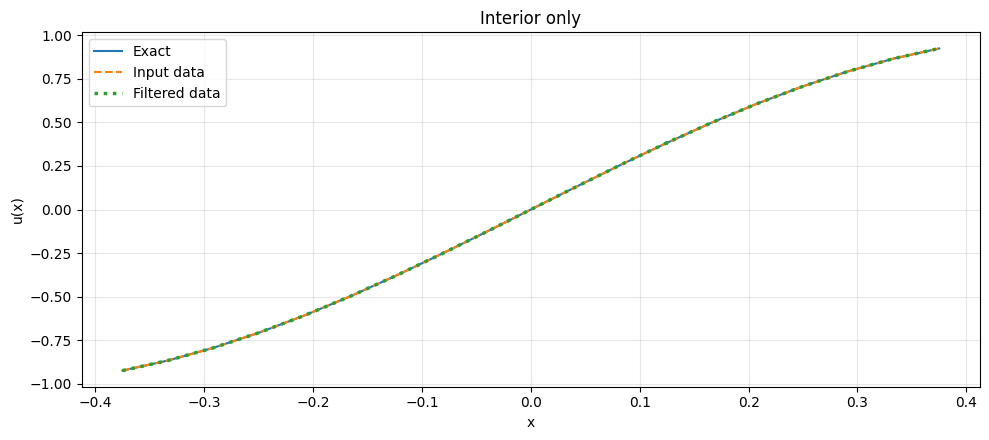

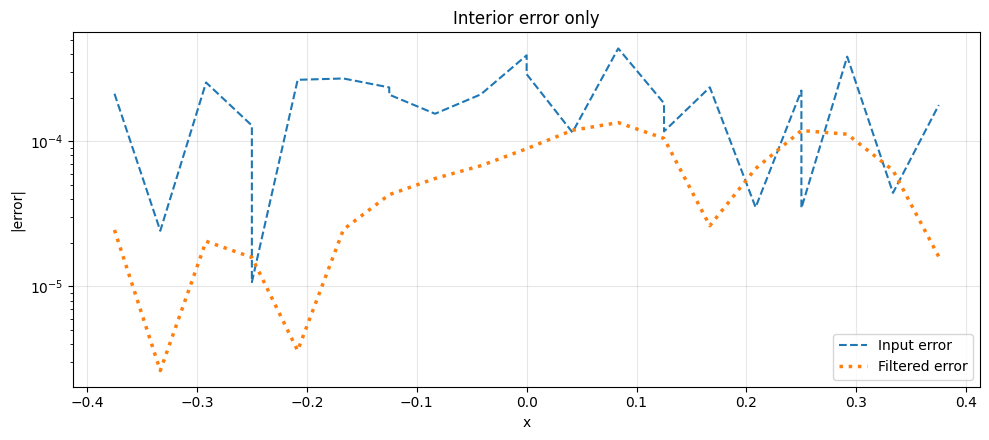

In [29]:
plot_siac_interior_only(y, fexact, coeffs_1d, V, ustar, halfker)

### 2D

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from src.metrics import rel_l2_err

def plot_siac_results_2d(X, Y, u_exact, U_dg, U_siac, order,
                         internal_only=(False, 0), title_prefix=""):

    Xp, Yp = X, Y
    uep, udp, usp = u_exact, U_dg, U_siac

    if internal_only[0]:
        halfker = int(internal_only[1])
        trim = halfker * order

        sl_y = slice(trim, -trim)
        sl_x = slice(trim, -trim)

        Xp = X[sl_y, sl_x]
        Yp = Y[sl_y, sl_x]
        uep = u_exact[sl_y, sl_x]
        udp = U_dg[sl_y, sl_x]
        usp = U_siac[sl_y, sl_x]

    err_dg = np.abs(uep - udp)
    err_siac = np.abs(uep - usp)

    # ---- shared solution normalization ----
    sol_min = min(np.min(uep), np.min(udp), np.min(usp))
    sol_max = max(np.max(uep), np.max(udp), np.max(usp))

    if np.isclose(sol_min, sol_max):
        pad = max(1e-12, 1e-6 * max(1.0, abs(sol_min)))
        sol_min -= pad
        sol_max += pad

    sol_norm = Normalize(vmin=sol_min, vmax=sol_max)

    # ---- shared error normalization ----
    err_max = max(err_dg.max(), err_siac.max())
    if np.isclose(err_max, 0.0):
        err_max = 1e-16

    err_norm = Normalize(vmin=0.0, vmax=err_max)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    extent = [Xp.min(), Xp.max(), Yp.min(), Yp.max()]

    im0 = axes[0, 0].imshow(uep, origin="lower", extent=extent, norm=sol_norm)
    axes[0, 0].set_title("Exact")

    im1 = axes[0, 1].imshow(udp, origin="lower", extent=extent, norm=sol_norm)
    axes[0, 1].set_title("DG reconstruction")

    im2 = axes[0, 2].imshow(usp, origin="lower", extent=extent, norm=sol_norm)
    axes[0, 2].set_title("SIAC filtered")

    im3 = axes[1, 1].imshow(err_dg, origin="lower", extent=extent, norm=err_norm)
    axes[1, 1].set_title("|Exact - DG|")

    im4 = axes[1, 2].imshow(err_siac, origin="lower", extent=extent, norm=err_norm)
    axes[1, 2].set_title("|Exact - SIAC|")

    axes[1, 0].axis("off")

    cbar1 = fig.colorbar(im0, ax=axes[0, :], location="right", shrink=0.85)
    cbar1.set_label("Solution value")

    cbar2 = fig.colorbar(im3, ax=axes[1, :], location="right", shrink=0.85)
    cbar2.set_label("Absolute error")

    suffix = " (interior only)" if internal_only[0] else ""
    fig.suptitle(f"{title_prefix}{suffix}", fontsize=14)

    plt.show()

    print(f"{title_prefix}{suffix}")
    # print(f"Exact min/max: {uep.min():.16e}, {uep.max():.16e}")
    # print(f"DG    min/max: {udp.min():.16e}, {udp.max():.16e}")
    # print(f"SIAC  min/max: {usp.min():.16e}, {usp.max():.16e}")
    
    dg_rel_l2 = rel_l2_err(x=udp, xtrue=uep)
    siac_rel_l2 = rel_l2_err(x=usp, xtrue=uep)
    
    print(f"DG:   max error: {err_dg.max():.3e},    rel. L2 error: {dg_rel_l2:.3e}")
    print(f"SIAC: max error: {err_siac.max():.3e},    rel. L2 error: {siac_rel_l2:.3e}")

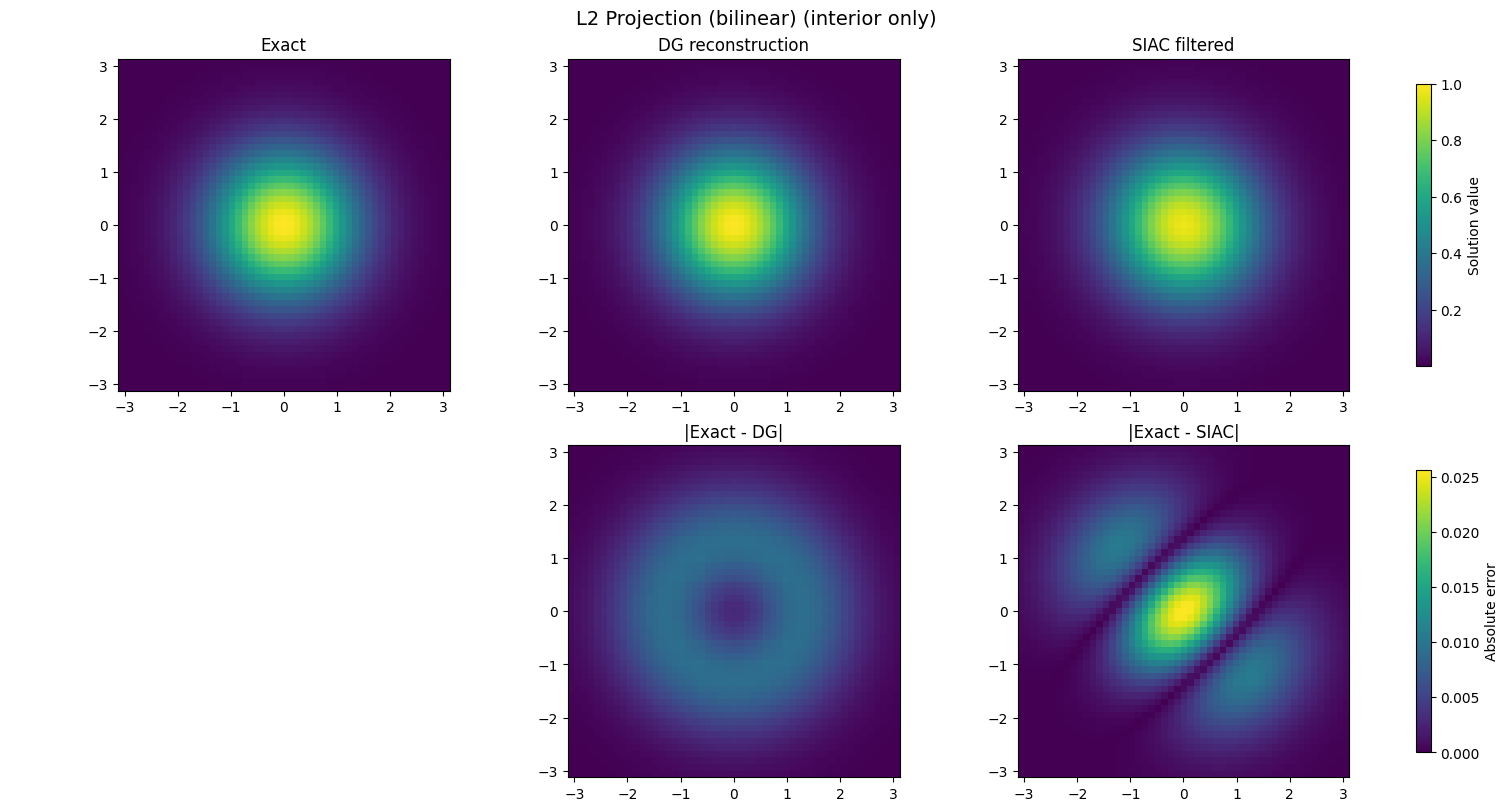

L2 Projection (bilinear) (interior only)
DG:   max error: 9.328e-03,    rel. L2 error: 1.758e-02
SIAC: max error: 2.557e-02,    rel. L2 error: 2.150e-02


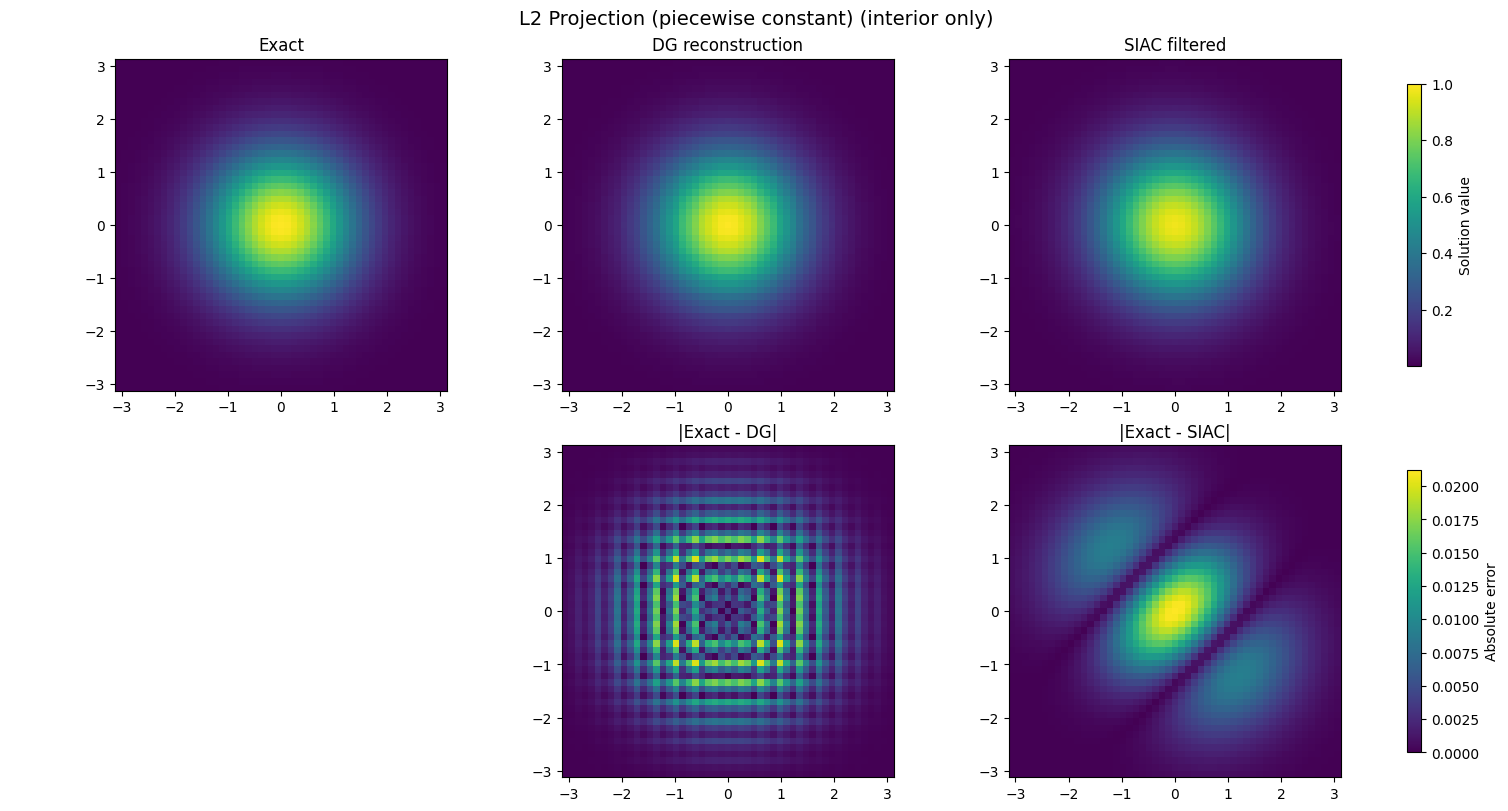

L2 Projection (piecewise constant) (interior only)
DG:   max error: 1.998e-02,    rel. L2 error: 1.967e-02
SIAC: max error: 2.119e-02,    rel. L2 error: 1.815e-02


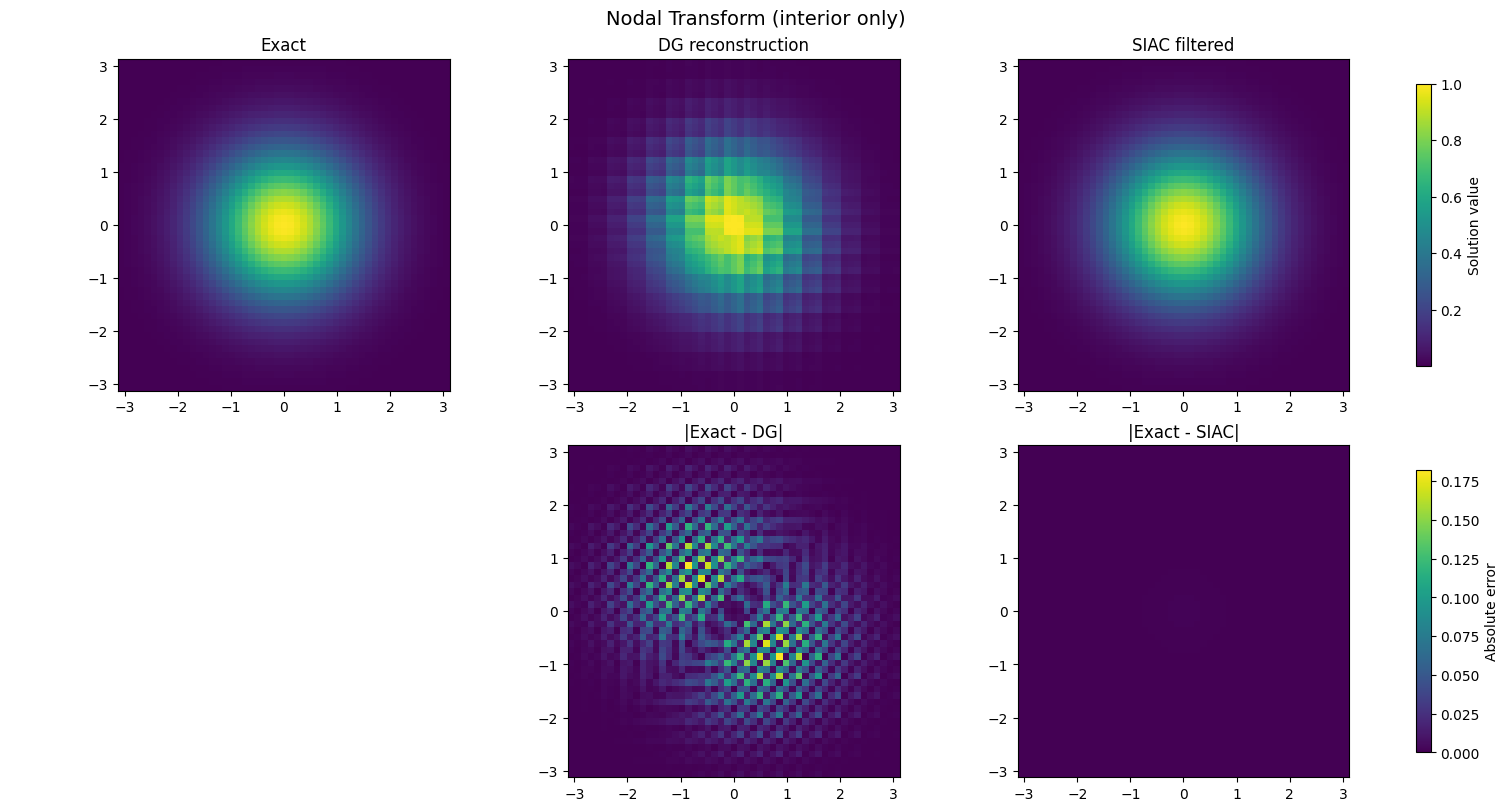

Nodal Transform (interior only)
DG:   max error: 1.821e-01,    rel. L2 error: 1.228e-01
SIAC: max error: 1.540e-03,    rel. L2 error: 1.036e-03


In [31]:
# 2D testing
def fexact2D_bubble(X, Y, xmin, xmax, ymin, ymax):
    bubble = (X - xmin) * (xmax - X) * (Y - ymin) * (ymax - Y) # (compact support on domain)
    return bubble / bubble.max()
    
def fexact2D_gaussian(X, Y):
    gaussian = np.exp(-0.5 * (X**2 + Y**2))
    return gaussian / gaussian.max()

def fexact2D_const(X, Y):
    return np.ones_like(X)

def fexact2D_composite(X, Y, domain):
    xmin, xmax, ymin, ymax = domain

    xhat = (X - xmin) / (xmax - xmin)
    yhat = (Y - ymin) / (ymax - ymin)

    Z = np.zeros_like(X)

    # square
    Z += np.where((xhat > 0.1) & (xhat < 0.3) & (yhat > 0.6) & (yhat < 0.9), 1.0, 0.0)

    # triangle
    tri = (xhat > 0.5) & (yhat > 0.2) & (yhat < xhat)
    Z[tri] += 0.8

    # ellipse
    ellipse = ((xhat - 0.7)/0.15)**2 + ((yhat - 0.7)/0.1)**2 <= 1.0
    Z[ellipse] += 0.5

    return Z


xmin, xmax = -5, 5
ymin, ymax = -5, 5

xgrid = np.linspace(xmin, xmax, 81)
ygrid = np.linspace(ymin, ymax, 81)

X, Y = np.meshgrid(xgrid, ygrid)

# u_exact = fexact2D_const(X, Y)
# u_exact = fexact2D_bubble(X, Y, xmin, xmax, ymin, ymax)
u_exact = fexact2D_gaussian(X, Y)

u_data = u_exact.copy()

# DG polynomial degree
deg = 2

# l2 projection
from src.dg_l2_projection import l2_project_image_to_dg
# Bilinear interpolator
dg_l2_bilinear = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="bilinear")
# Piecewise constant
dg_l2_const = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="piecewise_constant")

# nodal interpretation: nodal --> modal transform
from src.dg_nodal_transform import nodal_image_to_dg
dg_transform = nodal_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg)


# Immediate evaluation
from src.dg_utils import eval_dg_modal
U_l2_bilinear = eval_dg_modal(dg_l2_bilinear, X, Y)
U_l2_const = eval_dg_modal(dg_l2_const, X, Y)
U_transform = eval_dg_modal(dg_transform, X, Y)

# Apply SIAC to both
moments = 2 * deg
BSorder = deg + 1

from src.siac_modal import apply_siac_modal_dg
Ustar_l2_bilinear = apply_siac_modal_dg(dg_l2_bilinear, moments=moments, BSorder=BSorder)
Ustar_l2_const = apply_siac_modal_dg(dg_l2_const, moments=moments, BSorder=BSorder)
Ustar_transform = apply_siac_modal_dg(dg_transform, moments=moments, BSorder=BSorder)

order = deg + 1
halfker = int(np.ceil((moments + BSorder)/2)) + 1
internal_only = (True, halfker)

plot_siac_results_2d(X, Y, u_exact, U_l2_bilinear, Ustar_l2_bilinear, order, internal_only, title_prefix="L2 Projection (bilinear)")

plot_siac_results_2d(X, Y, u_exact, U_l2_const, Ustar_l2_const, order, internal_only, title_prefix="L2 Projection (piecewise constant)")

plot_siac_results_2d(X, Y, u_exact, U_transform, Ustar_transform, order, internal_only, title_prefix="Nodal Transform")

### With noise

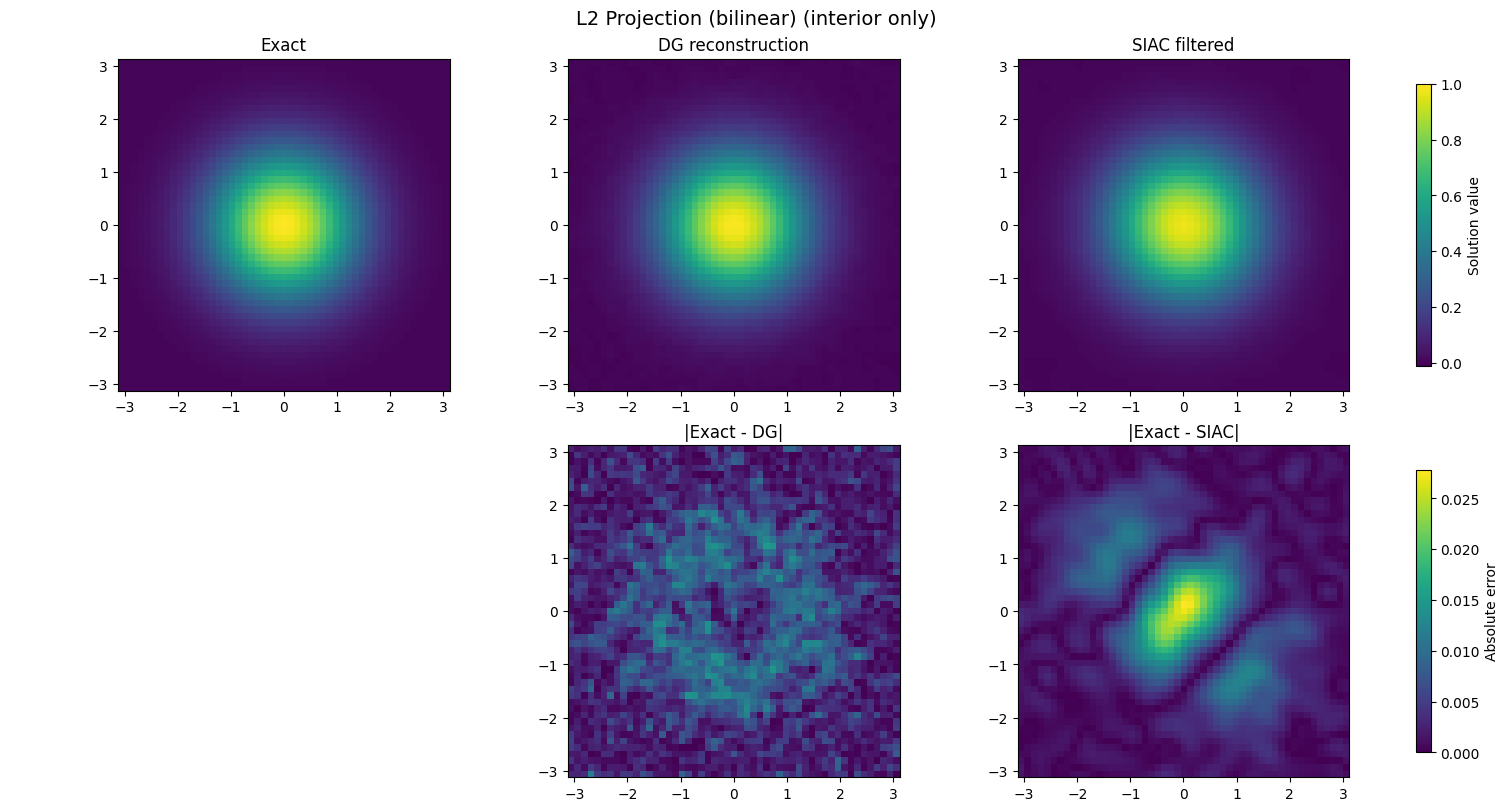

L2 Projection (bilinear) (interior only)
DG:   max error: 1.504e-02,    rel. L2 error: 2.008e-02
SIAC: max error: 2.778e-02,    rel. L2 error: 2.193e-02


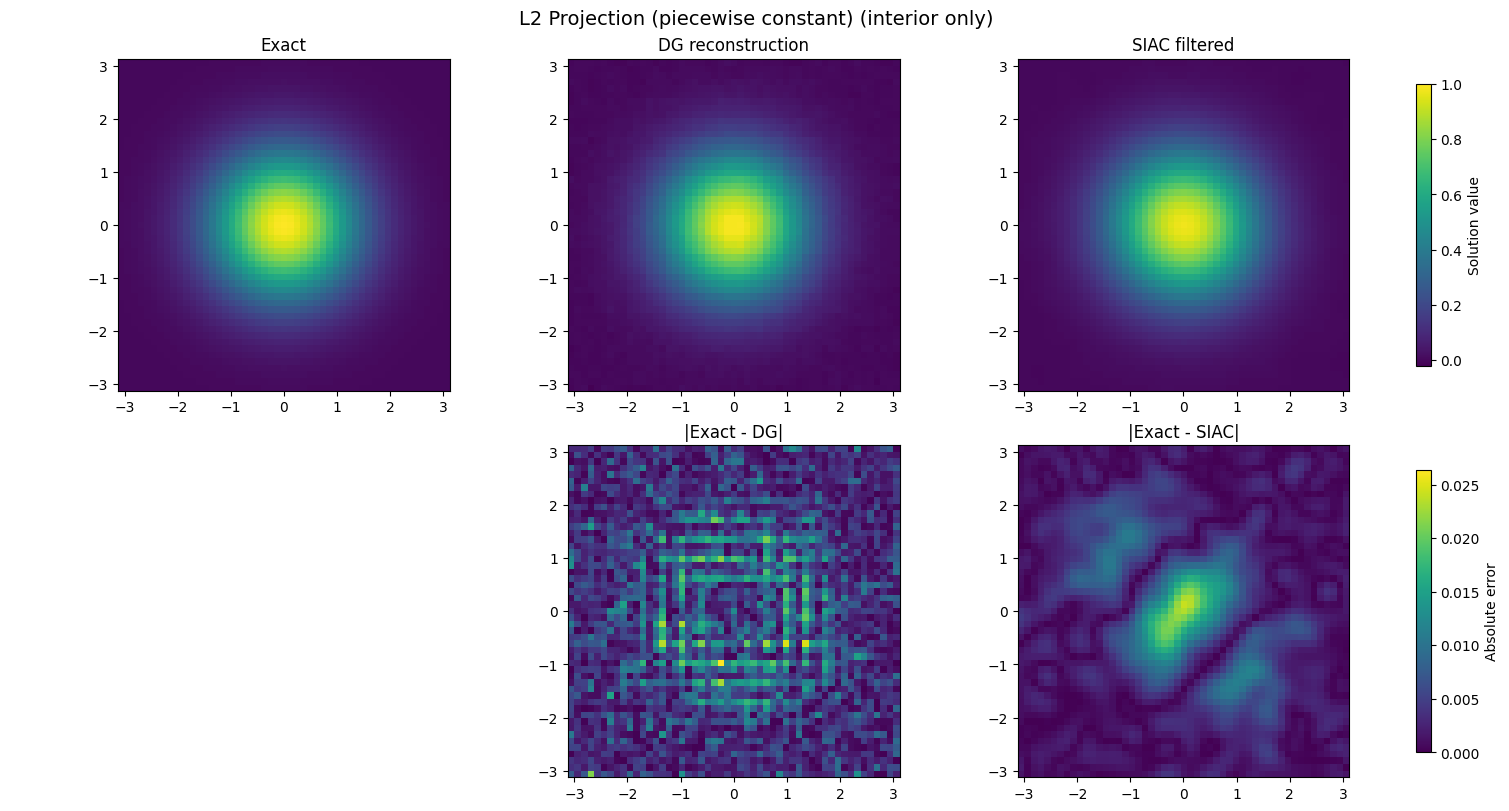

L2 Projection (piecewise constant) (interior only)
DG:   max error: 2.635e-02,    rel. L2 error: 2.427e-02
SIAC: max error: 2.411e-02,    rel. L2 error: 1.897e-02


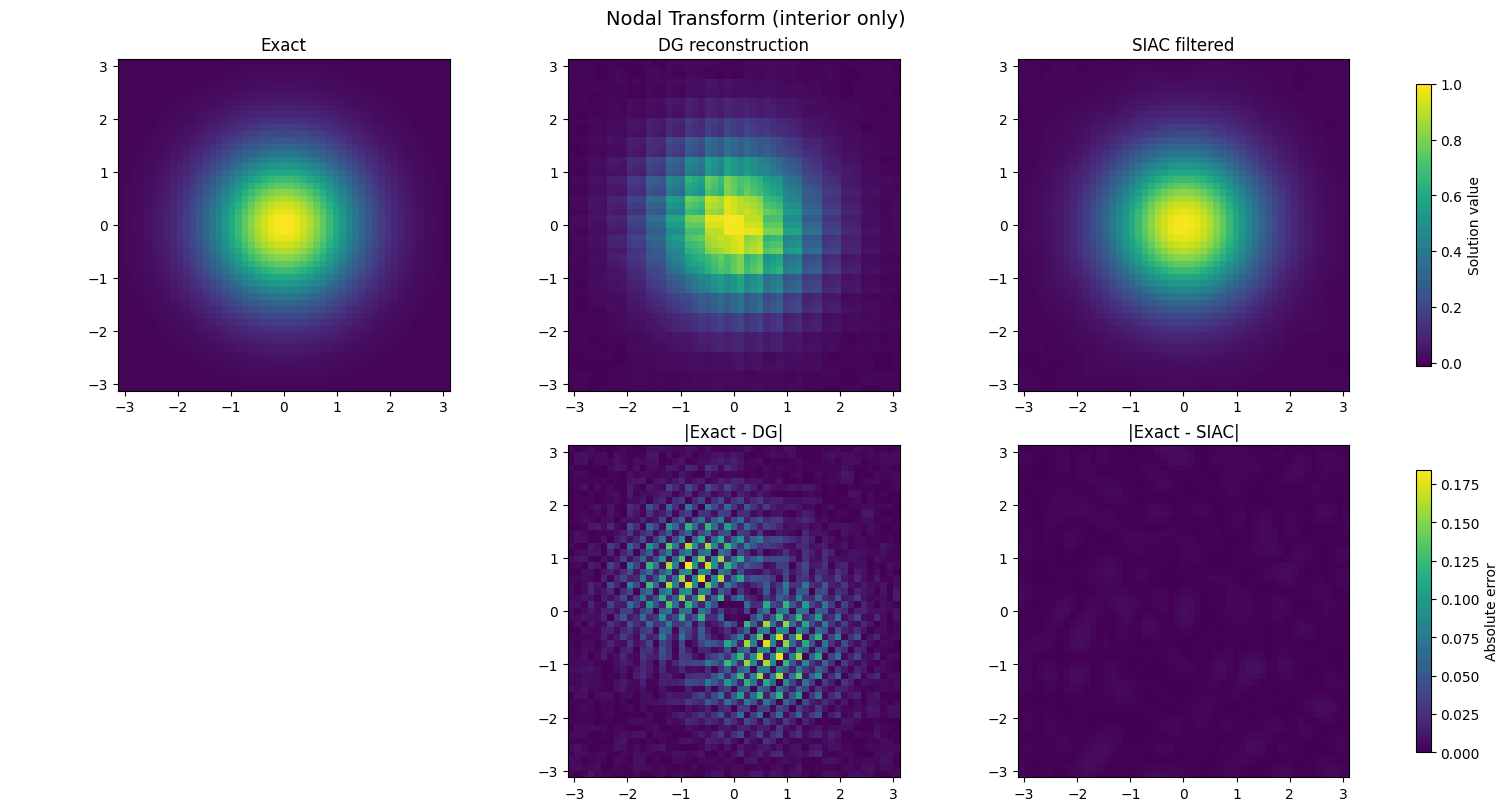

Nodal Transform (interior only)
DG:   max error: 1.841e-01,    rel. L2 error: 1.239e-01
SIAC: max error: 7.894e-03,    rel. L2 error: 7.566e-03


In [32]:
# 2D testing
def add_noise(u, dx, dy, deg, sigma=1.0, sigma_factor=None, seed=0):
    """
    Add Gaussian noise scaled like h^(DG order)
    """
    rng = np.random.default_rng(seed)
    
    h = np.sqrt(dx**2 + dy**2)
    scale = sigma * h**(deg + 1)

    # Validate sigma_factor
    if sigma_factor is not None:
        if not isinstance(sigma_factor, (int, float, np.floating)):
            raise ValueError("sigma_factor must be a number (int or float)")
        scale *= sigma_factor

    return u + scale * rng.standard_normal(u.shape)

xmin, xmax = -5, 5
ymin, ymax = -5, 5

xgrid = np.linspace(xmin, xmax, 81)
ygrid = np.linspace(ymin, ymax, 81)

X, Y = np.meshgrid(xgrid, ygrid)

# u_exact = fexact2D_const(X, Y)
# u_exact = fexact2D_bubble(X, Y, xmin, xmax, ymin, ymax)
u_exact = fexact2D_gaussian(X, Y)

u_data = add_noise(u_exact, 
                   dx = xgrid[1] - xgrid[0], 
                   dy = ygrid[1] - ygrid[0],
                   deg = deg, 
                   sigma = 1.0)

# DG polynomial degree
deg = 2

# l2 projection
from src.dg_l2_projection import l2_project_image_to_dg
# Bilinear interpolator
dg_l2_bilinear = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="bilinear")
# Piecewise constant
dg_l2_const = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="piecewise_constant")

# nodal interpretation: nodal --> modal transform
from src.dg_nodal_transform import nodal_image_to_dg
dg_transform = nodal_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg)


# Immediate evaluation
from src.dg_utils import eval_dg_modal
U_l2_bilinear = eval_dg_modal(dg_l2_bilinear, X, Y)
U_l2_const = eval_dg_modal(dg_l2_const, X, Y)
U_transform = eval_dg_modal(dg_transform, X, Y)

# Apply SIAC to both
moments = 2 * deg
BSorder = deg + 1

from src.siac_modal import apply_siac_modal_dg
Ustar_l2_bilinear = apply_siac_modal_dg(dg_l2_bilinear, moments=moments, BSorder=BSorder)
Ustar_l2_const = apply_siac_modal_dg(dg_l2_const, moments=moments, BSorder=BSorder)
Ustar_transform = apply_siac_modal_dg(dg_transform, moments=moments, BSorder=BSorder)

order = deg + 1
halfker = int(np.ceil((moments + BSorder)/2)) + 1
internal_only = (True, halfker)

plot_siac_results_2d(X, Y, u_exact, U_l2_bilinear, Ustar_l2_bilinear, order, internal_only, title_prefix="L2 Projection (bilinear)")

plot_siac_results_2d(X, Y, u_exact, U_l2_const, Ustar_l2_const, order, internal_only, title_prefix="L2 Projection (piecewise constant)")

plot_siac_results_2d(X, Y, u_exact, U_transform, Ustar_transform, order, internal_only, title_prefix="Nodal Transform")

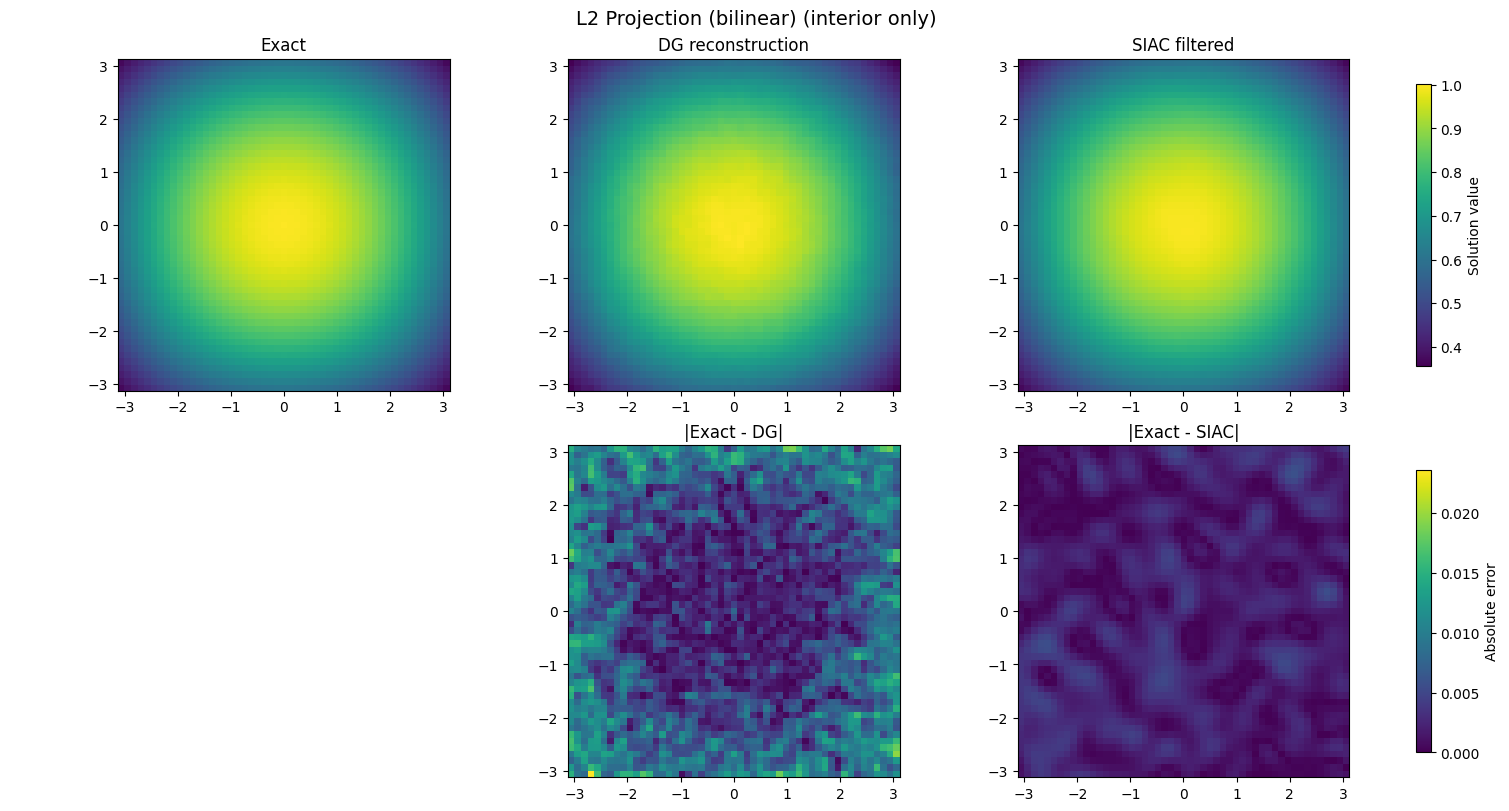

L2 Projection (bilinear) (interior only)
DG:   max error: 2.357e-02,    rel. L2 error: 9.823e-03
SIAC: max error: 5.779e-03,    rel. L2 error: 2.929e-03


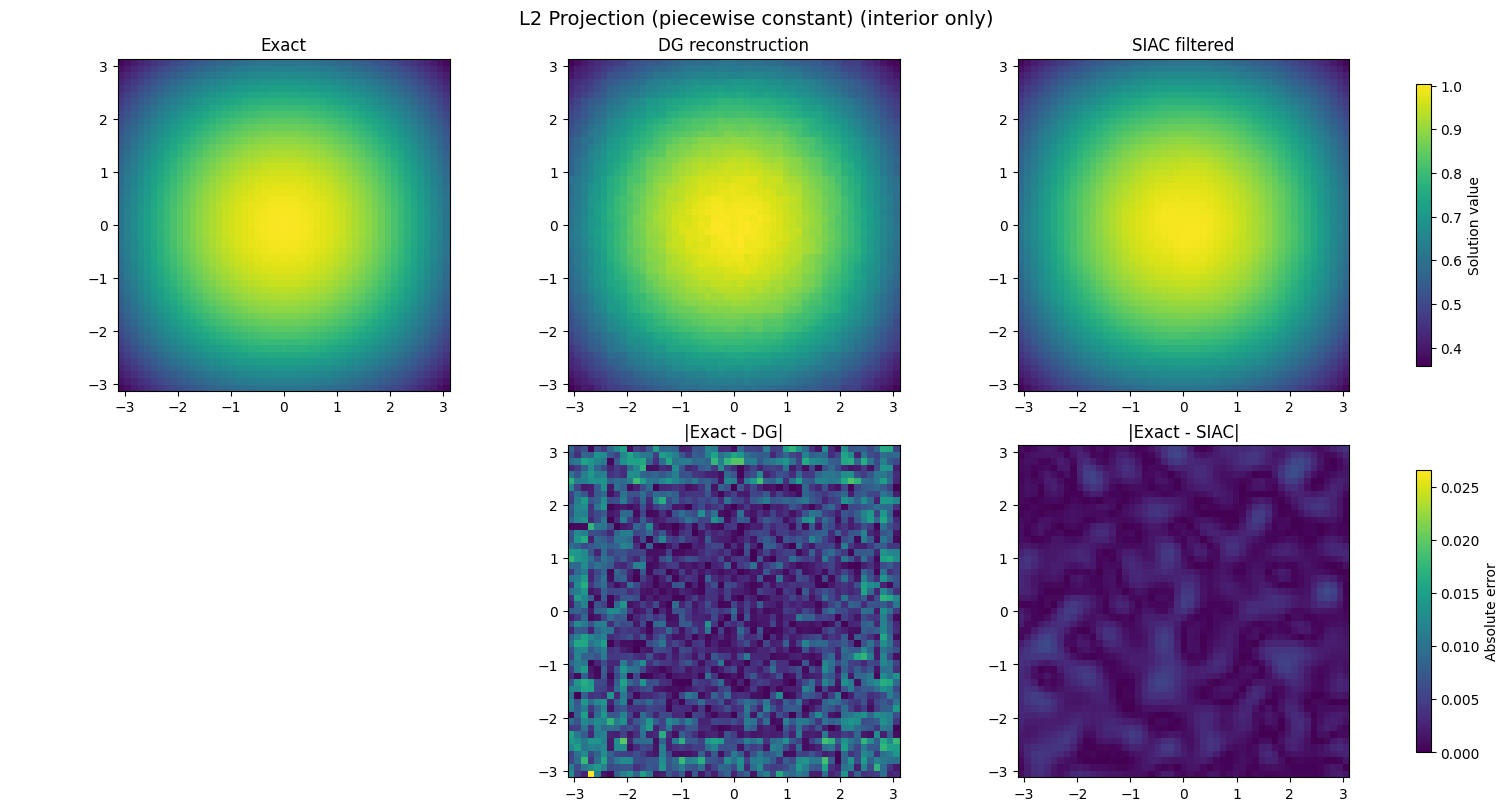

L2 Projection (piecewise constant) (interior only)
DG:   max error: 2.655e-02,    rel. L2 error: 9.673e-03
SIAC: max error: 6.468e-03,    rel. L2 error: 2.805e-03


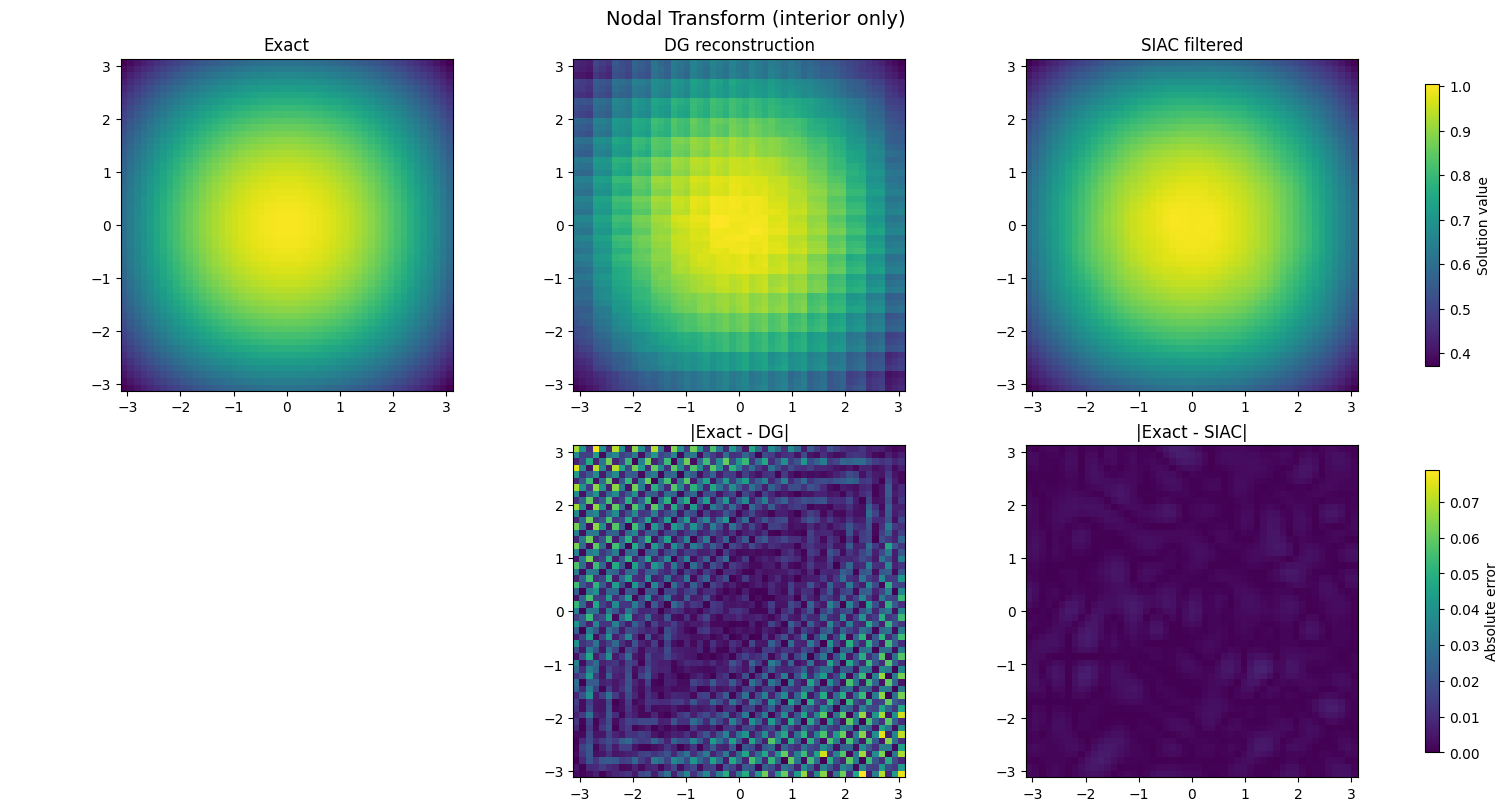

Nodal Transform (interior only)
DG:   max error: 7.886e-02,    rel. L2 error: 3.016e-02
SIAC: max error: 7.562e-03,    rel. L2 error: 2.715e-03


In [33]:



# u_exact = fexact2D_const(X, Y)
u_exact = fexact2D_bubble(X, Y, xmin, xmax, ymin, ymax)
# u_exact = fexact2D_gaussian(X, Y)

u_data = add_noise(u_exact, 
                   dx = xgrid[1] - xgrid[0], 
                   dy = ygrid[1] - ygrid[0],
                   deg = deg, 
                   sigma = 1.0)

# DG polynomial degree
deg = 2

# l2 projection
# Bilinear interpolator
dg_l2_bilinear = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="bilinear")
# Piecewise constant
dg_l2_const = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="piecewise_constant")

# nodal interpretation: nodal --> modal transform
dg_transform = nodal_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg)


# Immediate evaluation
U_l2_bilinear = eval_dg_modal(dg_l2_bilinear, X, Y)
U_l2_const = eval_dg_modal(dg_l2_const, X, Y)
U_transform = eval_dg_modal(dg_transform, X, Y)

# Apply SIAC to both
moments = 2 * deg
BSorder = deg + 1

Ustar_l2_bilinear = apply_siac_modal_dg(dg_l2_bilinear, moments=moments, BSorder=BSorder)
Ustar_l2_const = apply_siac_modal_dg(dg_l2_const, moments=moments, BSorder=BSorder)
Ustar_transform = apply_siac_modal_dg(dg_transform, moments=moments, BSorder=BSorder)

order = deg + 1
halfker = int(np.ceil((moments + BSorder)/2)) + 1
internal_only = (True, halfker)

plot_siac_results_2d(X, Y, u_exact, U_l2_bilinear, Ustar_l2_bilinear, order, internal_only, title_prefix="L2 Projection (bilinear)")

plot_siac_results_2d(X, Y, u_exact, U_l2_const, Ustar_l2_const, order, internal_only, title_prefix="L2 Projection (piecewise constant)")

plot_siac_results_2d(X, Y, u_exact, U_transform, Ustar_transform, order, internal_only, title_prefix="Nodal Transform")

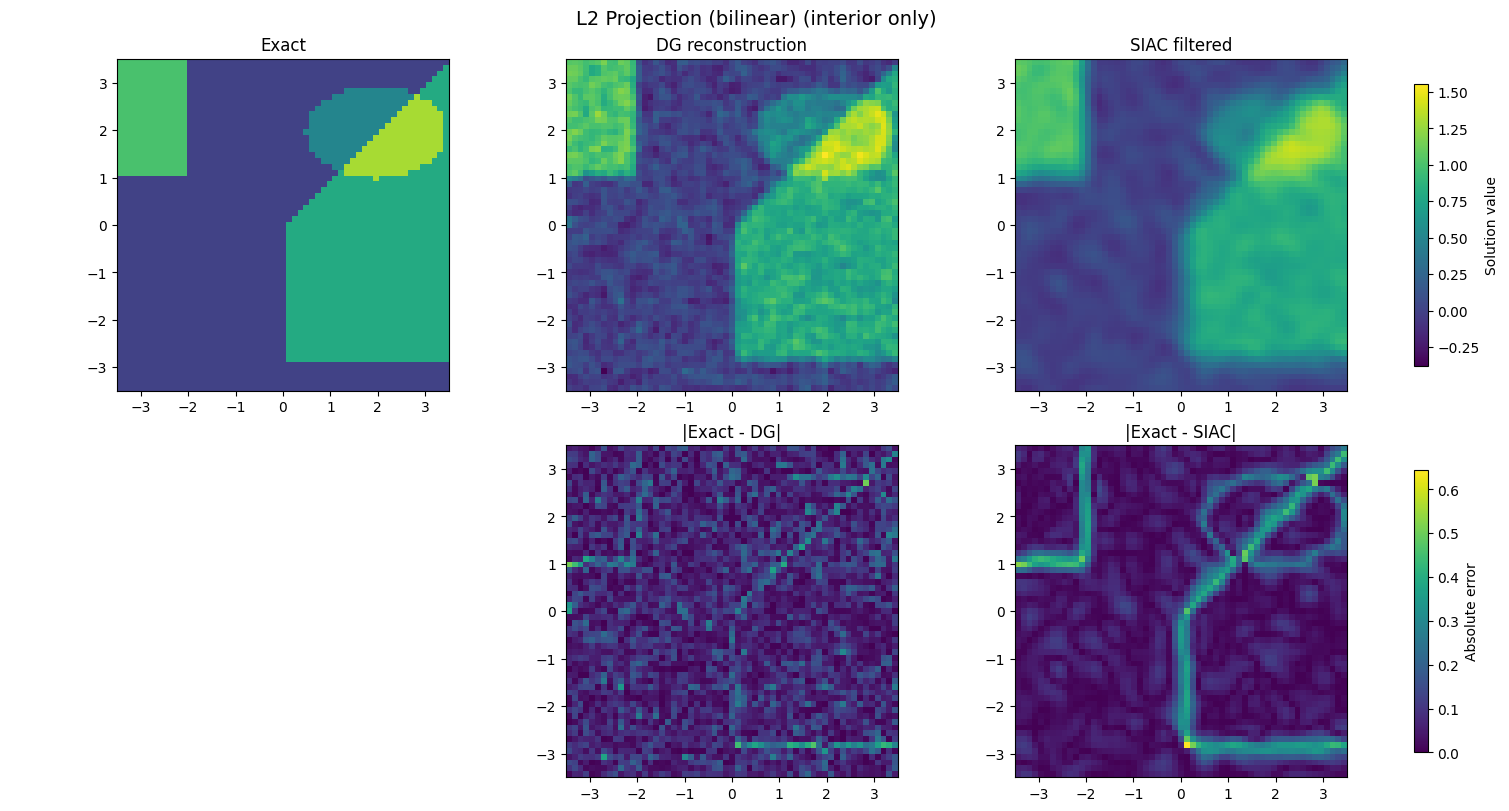

L2 Projection (bilinear) (interior only)
DG:   max error: 5.107e-01,    rel. L2 error: 1.844e-01
SIAC: max error: 6.437e-01,    rel. L2 error: 2.028e-01


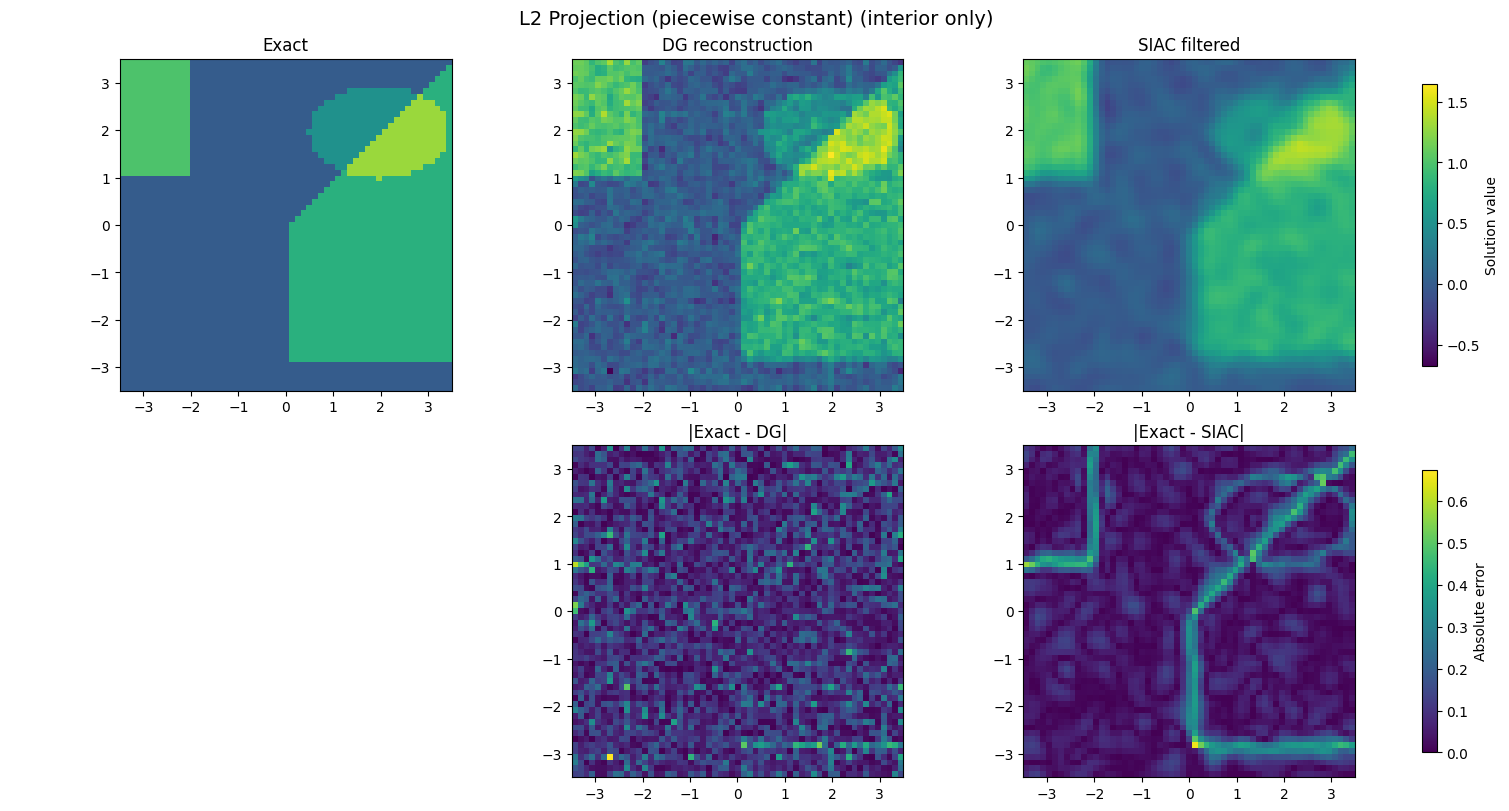

L2 Projection (piecewise constant) (interior only)
DG:   max error: 6.743e-01,    rel. L2 error: 2.385e-01
SIAC: max error: 6.606e-01,    rel. L2 error: 2.057e-01


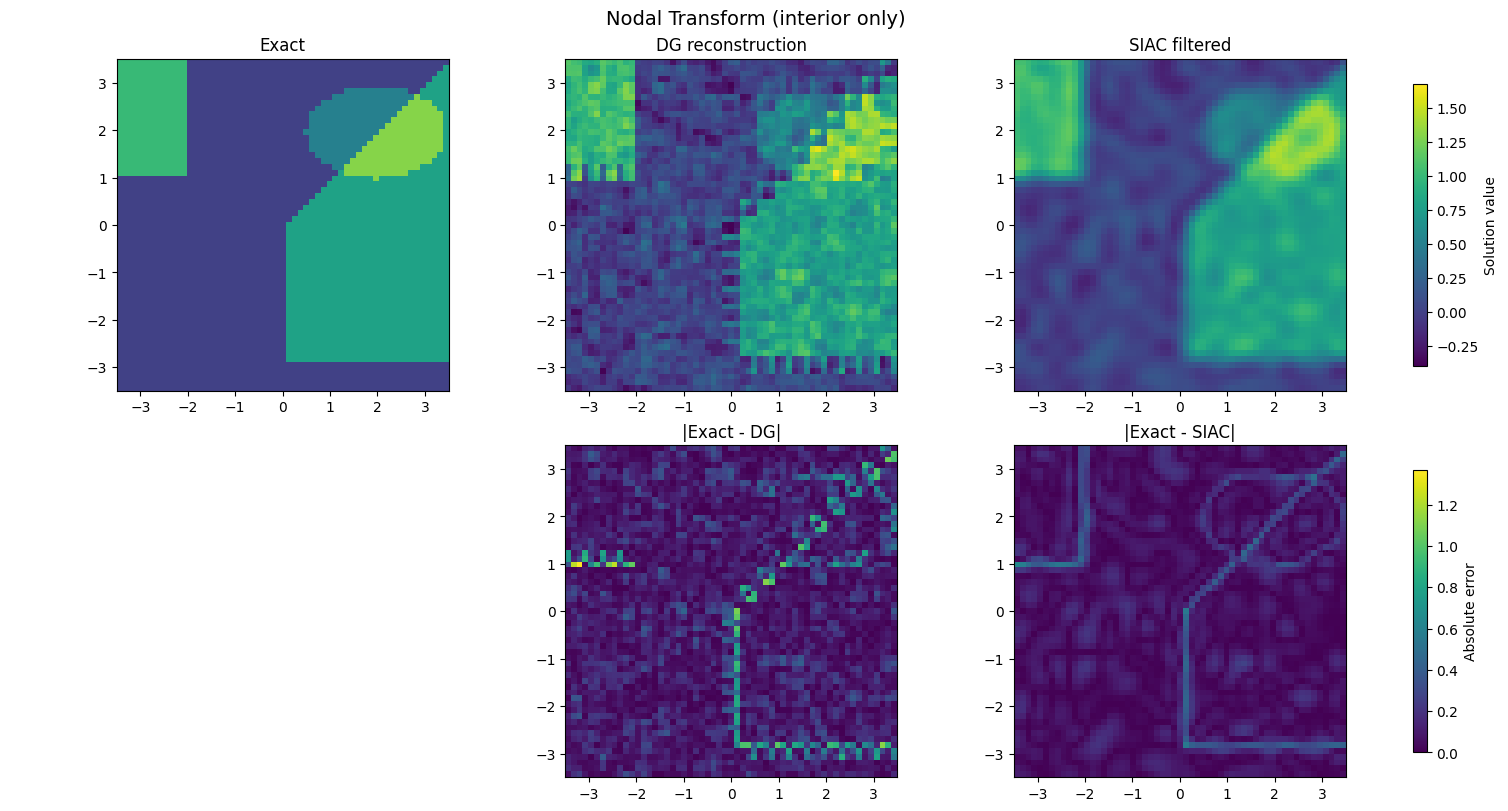

Nodal Transform (interior only)
DG:   max error: 1.367e+00,    rel. L2 error: 3.632e-01
SIAC: max error: 6.468e-01,    rel. L2 error: 1.977e-01


In [45]:

domain = (xmin, xmax, ymin, ymax)
u_exact = fexact2D_composite(X, Y, domain)


u_data = add_noise(u_exact, 
                   dx = xgrid[1] - xgrid[0], 
                   dy = ygrid[1] - ygrid[0],
                   deg = deg, 
                   sigma = 1.0, 
                   sigma_factor=10**1.5)

# DG polynomial degree
deg = 2

# l2 projection
# Bilinear interpolator
dg_l2_bilinear = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="bilinear")
# Piecewise constant
dg_l2_const = l2_project_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg, mode="piecewise_constant")

# nodal interpretation: nodal --> modal transform
dg_transform = nodal_image_to_dg(recon=u_data, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=deg)


# Immediate evaluation
U_l2_bilinear = eval_dg_modal(dg_l2_bilinear, X, Y)
U_l2_const = eval_dg_modal(dg_l2_const, X, Y)
U_transform = eval_dg_modal(dg_transform, X, Y)

# Apply SIAC to both
moments = 2 * deg
BSorder = 2

Ustar_l2_bilinear = apply_siac_modal_dg(dg_l2_bilinear, moments=moments, BSorder=BSorder)
Ustar_l2_const = apply_siac_modal_dg(dg_l2_const, moments=moments, BSorder=BSorder)
Ustar_transform = apply_siac_modal_dg(dg_transform, moments=moments, BSorder=BSorder)

order = deg + 1
halfker = int(np.ceil((moments + BSorder)/2)) + 1
internal_only = (True, halfker)

plot_siac_results_2d(X, Y, u_exact, U_l2_bilinear, Ustar_l2_bilinear, order, internal_only, title_prefix="L2 Projection (bilinear)")

plot_siac_results_2d(X, Y, u_exact, U_l2_const, Ustar_l2_const, order, internal_only, title_prefix="L2 Projection (piecewise constant)")

plot_siac_results_2d(X, Y, u_exact, U_transform, Ustar_transform, order, internal_only, title_prefix="Nodal Transform")

**Comparison of reconstruction strategies.**
In the noiseless case, the nodal-to-modal transformation consistently provides the most accurate approximation, since it corresponds to an exact interpolation of the sampled data in the DG polynomial space. In contrast, the $L^2$ projection methods introduce an additional modeling step, either through bilinear interpolation or a piecewise constant representation, which leads to a small but systematic approximation error.

When noise is introduced, the relative performance of the methods depends on the structure of the underlying function. For the compactly supported bubble function, the $L^2$ projection with bilinear interpolation yields the smallest error, followed by the piecewise constant model, while the nodal-to-modal approach exhibits the largest error. This behavior can be attributed to the smoothing effect inherent in the projection, which reduces high-frequency noise components. 

On the other hand, for the smooth Gaussian function, the nodal-to-modal method performs best, while the bilinear $L^2$ projection performs worst, with the piecewise constant approach lying in between. In this case, the additional interpolation error dominates over the noise reduction, and preserving the original sample values becomes advantageous. 

Overall, these results demonstrate that the choice of reconstruction strategy reflects a balance between noise robustness and approximation fidelity, and should be adapted to the assumed data model and regularity properties of the underlying field.

In [35]:
# testing einstein summation convention instead of loop in SIAC modal code

import numpy as np

order = 4
kernellength = 8

rng = np.random.default_rng(0)

Sy = rng.normal(size=(order, kernellength))
Sx = rng.normal(size=(order, kernellength))
block = rng.normal(size=(kernellength, kernellength, order, order))

# loop version
val_loop = 0.0
for ry in range(kernellength):
    for rx in range(kernellength):
        for my in range(order):
            for mx in range(order):
                val_loop += (
                    Sy[my, ry] * Sx[mx, rx] * block[ry, rx, my, mx]
                )

# einsum version
val_einsum = np.einsum('mr,ns,rsmn->', Sy, Sx, block, dtype=float)

print("loop  :", val_loop)
print("einsum:", val_einsum)
print("close :", np.allclose(val_loop, val_einsum))
print("diff  :", abs(val_loop - val_einsum))

loop  : -12.871048413311586
einsum: -12.871048413311609
close : True
diff  : 2.3092638912203256e-14


In [36]:
import numpy as np

rng = np.random.default_rng(0)

for order in [1, 2, 3, 4]:
    for kernellength in [1, 2, 5]:
        for _ in range(10):
            Sy = rng.normal(size=(order, kernellength))
            Sx = rng.normal(size=(order, kernellength))
            block = rng.normal(size=(kernellength, kernellength, order, order))

            val_loop = 0.0
            for ry in range(kernellength):
                for rx in range(kernellength):
                    for my in range(order):
                        for mx in range(order):
                            val_loop += (
                                Sy[my, ry] * Sx[mx, rx] * block[ry, rx, my, mx]
                            )

            val_einsum = np.einsum('mr,ns,rsmn->', Sy, Sx, block)

            assert np.allclose(val_loop, val_einsum), (
                order, kernellength, val_loop, val_einsum
            )

print("All tests passed.")

All tests passed.
